<div style="border:solid Chocolate 2px; padding: 40px">
 
<b> Марина, привет!👋</b> 

Меня зовут Кирилл Васильев, я буду ревьюером твоего проекта. Я предлагаю общаться на «ты», но если привычнее на «вы», просто скажи об этом! 

Я буду оставлять комментарии в твоем проекте. Пожалуйста, не удаляй их, они могут быть полезны в случае повторной проверки.

Свои комментарии я буду обозначать <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:
  
<br/> 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным. Здесь же я могу давать советы и предложения.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div> 
  

<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
 
   
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>  

<br/>
<div class="alerфt alert-info">
Рекомендую для твоих комментариев использовать синий или любой другой цветной фон. Я постараюсь ничего не пропустить, но если комментарии будут выделены, то это мне очень поможет!
</div>
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самостоятельно найти и исправить ее. На реальной работе твой руководитель будет поступать также. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку.



# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

Мовсумова Марина

# План работы

**Цель проекта**:

Построить модель, которая прогнозирует вероятность оттока клиента (churn) в следующем месяце, чтобы компания могла заранее выявлять клиентов с риском ухода

**Задачи проекта**:

- Провести исследовательский анализ данных (EDA)
- Подготовить данные: обработать пропуски и признаки
- Построить модель логистической регрессии
- Оценить качество модели с помощью метрик 
- Улучшить модель за счёт отбора и создания признаков
- Подобрать гиперпараметры
- Обучить финальную модель и сохранить её вместе с пайплайном

# Постановка задачи машинного обучения

Необходимо решить задачу машинного обучения для прогнозирования вероятности оттока клиентов сервиса доставки кофе.

Тип задачи машинного обучения: бинарная классификация.

Целевая переменная: факт оттока клиента (столбец churn датафрейма), где 1 — клиент ушёл, 0 — клиент остался.

Модель должна быть линейной, чтобы обеспечить интерпретируемость результатов и возможность анализа влияния признаков на отток клиентов.

Основная метрика — Precision-Recall AUC (PR-AUC), так как данные могут быть несбалансированы, и важно корректно выявлять клиентов, склонных к уходу.

Дополнительные метрики — ROC-AUC, Precision, Recall, F1-мера.

Для успешного решения задачи необходимо достичь качества модели, превосходящего базовую модель (DummyClassifier), и обеспечить разумный баланс между точностью и полнотой.

Данные будут разделены на обучающую и тестовую выборки с использованием кросс-валидации для оценки устойчивости модели.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично по описанию. Цели и задачи ясны, обозначены корректно. Итак, решаем задачу бинарной классификации.
 

# Оглавление

1. [Этап 1. Подготовка среды и библиотек](#section1)
2. [Этап 2. Первичный анализ данных](#section2)
3. [Этап 3. Предобработка данных](#section3)
4. [Этап 4. Обучение модели](#section4)
5. [Этап 5. Создание новых признаков](#section5)
6. [Этап 6. Эксперименты с гиперпараметрами](#section6)
7. [Этап 7. Подготовка финальной модели](#section7)
8. [Этап 8. Отчёт о проделанной работе](#section8)
9. [Этап 9. Сохранение модели для продакшена](#section9)

<a id='section1'></a>
## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
! pip install phik

In [3]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import sklearn
import matplotlib
import seaborn
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate


<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>

Здесь лучше явно прописать кодом инсталлы и важно убедиться, что все будет отрабатывать без падений в среде Практикума. Для нас это среда заказчика, мы должны сдать работающее решение.

In [5]:
random_state = 42

In [6]:
df = pd.read_csv('coffee_churn_dataset.csv', sep=",", decimal='.')

<a id='section2'></a>
## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

In [8]:
df.head(5)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Данные представляют собой агрегированную информацию о пользователях сервиса доставки кофе за последние 4 недели. Каждая строка соответствует одному уникальному клиенту.

В датасете содержатся признаки, характеризующие поведение пользователей:
- активность (частота заказов, количество открытий приложения),
- финансовые показатели (средний чек, сумма покупок),
- взаимодействие с сервисом (использование скидок, уведомлений, наличие сбоев приложения),
- предпочтения (тип кофе, обжарка, размер напитка, тип молока),
- а также технические и региональные характеристики (тип устройства, регион).

Большинство признаков являются потенциально информативными для задачи прогнозирования оттока, так как отражают активность и вовлечённость клиента. 

Признак user_id не несёт полезной информации для модели, так как является уникальным идентификатором пользователя и не связан с его поведением, его можно удалить.

In [9]:
df = df.drop(columns=['user_id'])


<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>

Можем удалить дублирующие признаки, однако я бы это сделал как минимум после корреляционного анализа, а лучше - после исследования весов признаков в моделях. Все-таки признаки разные. Возможно, мы можем взять разность между частотой заказов в месяц и в неделю как признак изменения интереса к продукту, этот признак может быть связан с таргетом и быть полезным. Просто не глядя в самом начале проекта убирать признаки, которые потенциально могут быть полезными, не нужно. Так мы пропустим оптимальное решение.
    
Если переформулировать знаменитую формулу, признаки с низкой корреляцией могут быть «карликами на плечах великанов», они не дают суперхорошего вклада в качество, но все-таки повышают его. С ними модель может быть качественнее, чем без них.    
 
***
    
В целом решение логичное, но давай перенесем его на ПОСЛЕ корреляционного анализа. Ну или удалим в части, где ты доказываешь, что признак геолокации не важен, там же можем уточниться и по остальным -  это будет уже с максимальной наглядностью, тут риск ошибиться будет уже околонулевым.

In [10]:
clients_df = pd.DataFrame({
    'abs': df['churn'].value_counts(),
    'real': df['churn'].value_counts(normalize=True)
})

clients_df

,abs,real
churn,,
0,9821,0.939809
1,629,0.060191


Целевая переменная -- столбец churn, отражает факт оттока клиентов:
1 -- клиент перестал пользоваться сервисом,
0 -- клиент остался.

Анализ распределения показал, что классы распределены неравномерно: доля клиентов, оставшихся в сервисе, значительно превышает долю ушедших клиентов. Таким образом, наблюдается дисбаланс классов.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Дисбаланс есть и он существенный, впрочем это ожидаемо для задачи оттока



In [11]:
missing_df = pd.DataFrame({
    'abs': df.isna().sum(),
    'real': round(df.isna().mean(), 3)
})

missing_df

,abs,real
days_since_last_order,945,0.090
order_frequency_month,600,0.057
order_frequency_week,388,0.037
avg_order_value,583,0.056
median_order_value,831,0.080
total_spent_last_month,294,0.028
total_spent_last_week,944,0.090
discount_usage_rate,397,0.038
last_coffee_type,258,0.025
preferred_roast,116,0.011



<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Также полезно подсчитать, какая доля строк имеет хотя бы один пропуск

```
# Сколько строк имеют хотя бы один пропуск
rows_with_nan = df.isna().any(axis=1).sum()
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_nan} из {len(df)} "
      f"({rows_with_nan/len(df)*100:.2f}%)")

```

В датасете присутствуют пропущенные значения как в числовых, так и в категориальных признаках.
Доля пропусков варьируется примерно от 1% до 10% в разных столбцах.
Наибольшая доля пропущенных значений (около 8–10%) наблюдается в признаках, связанных с активностью пользователей и взаимодействием с сервисом (например, seasonal_menu_tried (9.5%), days_since_last_order (9%), total_spent_last_week (9%), subscription_status (9%) и тд.
В ряде признаков доля пропусков невысока (около 1–3%) (preferred_roast (1.1%), geo_location(1.1%), last_coffee_type(2.5%), total_spent_last_month (2.8%)), а в целевой переменной и идентификаторе пользователя пропуски отсутствуют.

Удаление строк в таком количестве кажется нецелесообразным, так как есть опасность потерять значимое количество данных. В связи с этим пропуски в числовых признаках будут заполнены, а сами признаки масштабированы (StandardScaler / MinMaxScaler) и заполнены медианным значением. Пропуски в категориальных признаках будут заполнены наиболее частым значением (модой) и сдалее признаки будут закодированы (OneHotEncoder).


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Верно по решению и аргументации.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Опять же, пока не исследовали данные говорить о создании новых признаков преждевременно. Мы же должны принимать решения основываясь на данных, верно? Чем мы здесь аргументируем, почему предлагаемые признаки «более информативные»? Какой смысл в total_spent_last_month / order_frequency_month и почему ты называешь это «средние чеки пользователей за год», где там год? 
    
А какой смысл в `app_opens_per_week * order_frequency_week` ? 

<div class="alerфt alert-info">
В задании сказано указать возможные стратегии для создания новых признаков, поэтому я это и делала на этом этапе. Хотя потом все равно пришлось возвращаться и подгонять под то, что получилось сильно позже на этапе создания этих самых признаков.

Это средние чеки за месяц, а не за год, конечно. Если я правильно понимаю, то если посмотреть отношение количества заказов в месяц и сумму в месяц, то можем узнать, сколько примерно тратит клиент за один заказ. Может он заказывает редко, но тратит много, значит важный клиент. Может наоборот заказывает часто, но в среднем чек меньше. То есть смотрим на тип потребления, что тоже может быть полезным в плане прогнозирования оттока, мне кажется.

Про второй признак -- это я как-то думала учесть интенсивность взаимодействия пользователя и приложения. Думала, что сочетание частых открытий приложения и количество заказов могут как-то показать уровень вовлеченности пользователя.

Вообще, если честно, то если с логарифмированием, квадратом и корнем мне всё понятно, то вот про отношения признаков пока сложнее, поэтому могла наворотить. (: 
</div>

In [12]:
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [13]:
temp = df.copy() #копия датасета до преобразования для возможности проверить сделанные изменения после обработки

In [14]:
num_features = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo',
    'app_opens_per_week'
]
mask_errors = (df[num_features] < 0).any(axis=1)

errors_total = mask_errors.sum()

errors_total

np.int64(8)

In [15]:
df = df[~(df[num_features] < 0).any(axis=1)]

In [16]:
a, b = len(temp), len(df)
print(" Было строк в датасете до фильтрации", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в датасете до фильтрации 10450 
 Осталось строк в датасете после обработки 10442 
 Удалено строк в датасете после обработки 8 
 Процент потерь 0.08


В ходе анализа данных были выявлены некорректные значения в ряде числовых признаков, в частности отрицательные значения в показателях, где они невозможны по смыслу (например, суммы трат, частота заказов, количество открытий приложения и оценки пользователей).

Такие значения были интерпретированы как ошибки данных, поскольку они противоречат логике предметной области.

Доля строк, содержащих хотя бы одно некорректное значение, составила около 0.8% от общего объёма данных. Учитывая небольшую долю таких наблюдений, было принято решение удалить соответствующие строки из выборки, чтобы избежать искажения распределений признаков и повышения шума в данных.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 ОК, удаляем отрицательные. 
    
В принципе, они могут быть возвратами, можем попробовать что-то вытащить из этой гипотезы, но и удаление будет логичным, количество таких строк минимально. 

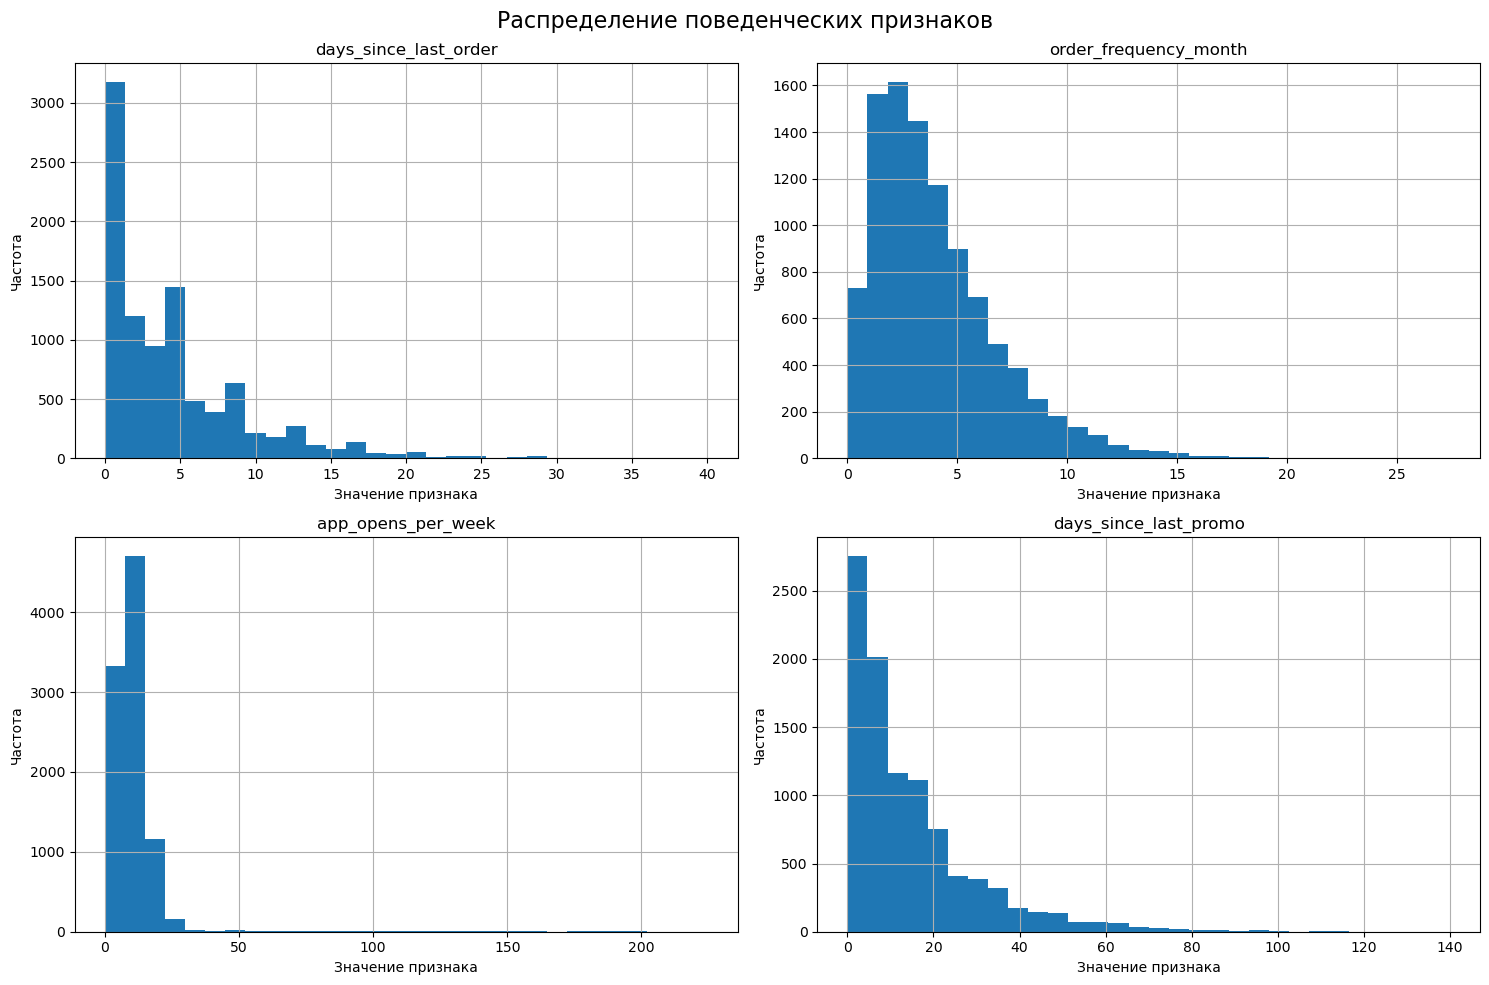

In [17]:
behavior_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'app_opens_per_week',
    'days_since_last_promo'
]

axes = df[behavior_cols].hist(figsize=(15, 10), bins=30)

for ax in axes.flatten():
    ax.set_xlabel('Значение признака')
    ax.set_ylabel('Частота')

plt.suptitle('Распределение поведенческих признаков', fontsize=16)
plt.tight_layout()
plt.show()

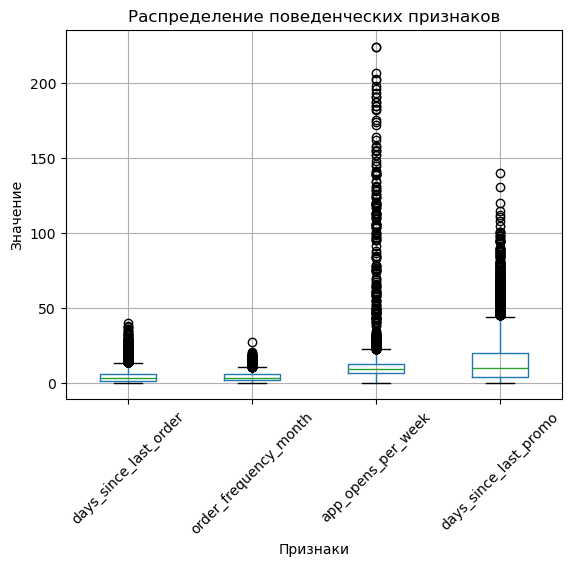

In [18]:
df[behavior_cols].boxplot(rot=45)

plt.title('Распределение поведенческих признаков')
plt.xlabel('Признаки')
plt.ylabel('Значение')

plt.show()

Распределения поведенческих признаков показывают, что большинство из них имеют правостороннюю асимметрию: основная масса значений сосредоточена в области небольших значений, при этом наблюдаются длинные «хвосты» справа.
выбросы. Наиболее выраженные выбросы наблюдаются в признаках, связанных с активностью пользователей (app_opens_per_week) и давностью использования акций (days_since_last_promo). При этом выбросы не являются единичными и, вероятно, отражают реальные особенности поведения пользователей, поэтому их удаление нецелесообразно. Для уменьшения влияния асимметрии может быть рассмотрено применение логарифмического преобразования.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Здесь абсолютно верно по оценке распределений и предложениям.

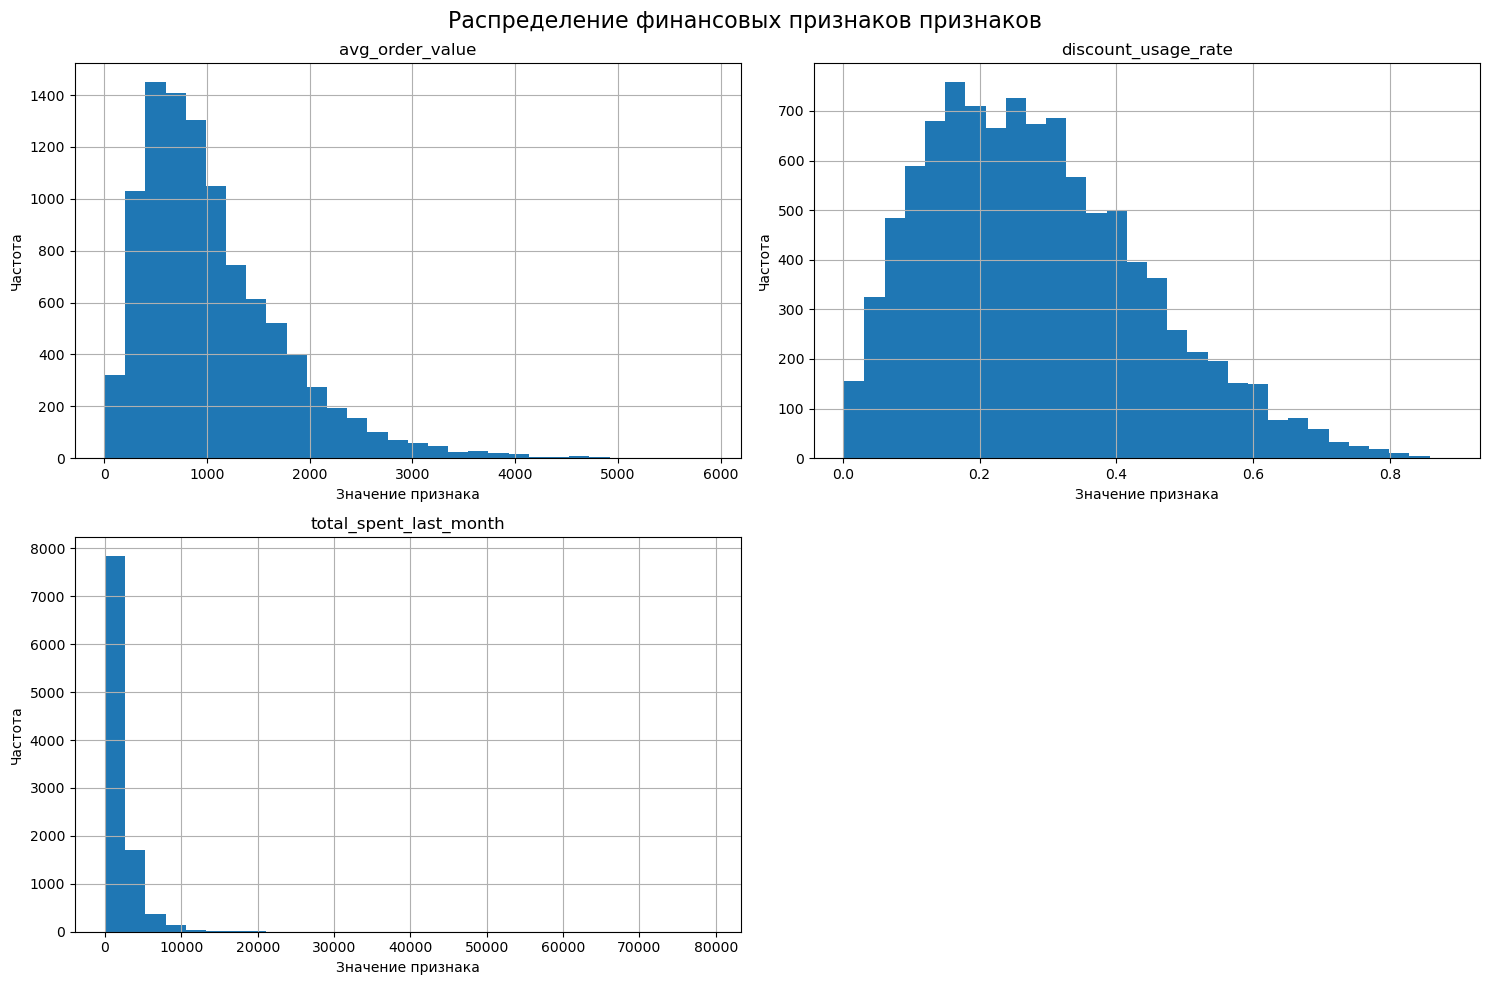

In [19]:
financial_cols = [
    'avg_order_value',
    'discount_usage_rate',
    'total_spent_last_month'
]

axes = df[financial_cols].hist(figsize=(15, 10), bins=30)

for ax in axes.flatten():
    ax.set_xlabel('Значение признака')
    ax.set_ylabel('Частота')

plt.suptitle('Распределение финансовых признаков признаков', fontsize=16)
plt.tight_layout()
plt.show()

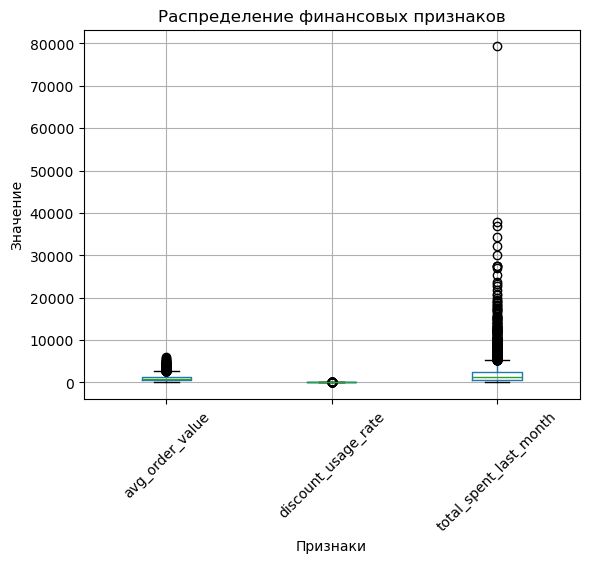

In [20]:
df[financial_cols].boxplot(rot=45)

plt.title('Распределение финансовых признаков')
plt.xlabel('Признаки')
plt.ylabel('Значение')

plt.show()

Анализ распределений финансовых признаков показал, что большинство из них также имеют правостороннюю асимметрию. Основная масса значений сосредоточена в области небольших и средних значений, при этом наблюдаются длинные правые «хвосты».

Наиболее выраженные выбросы наблюдаются в признаке total_spent_last_month, где присутствуют значения, значительно превышающие основную часть распределения. Однако даже такое значение может быть естественным поведением пользователя (например, корпоративный клиент или заказ на мероприятие), так что было принято решение его оставить. Для снижения влияния ассиметрии в дальнейшем будут применены нелинейные преобразования признаков (извлечение корня). 

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
`Однако даже такое значение может быть естественным поведением пользователя (например, корпоративный клиент или заказ на мероприятие), так что было принято решение его оставить. `
    
Да, поведение то может быть естественным, но клиент такой явно не наша целевая аудитория. С точки зрения статистик он представляет собой экстремальное значение, что в теории не очень хорошо для моделей. Можем его как удалить, так и оставить. Я бы удалил.

<div class="alerфt alert-info">
Я его сначала удалила, потому что подумала, что он такой один, что угодно в целом может значить, как ошибку при вводе данных, так и нормальное поведение, но в любом случае слишком уж большой. Но потом вернула обратно, так как побаиваюсь что-то удалять лишний раз.
</div>

In [21]:
df = df[df['total_spent_last_month'] <= 40000]

In [22]:
interval_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo',
    'median_order_value', 
    'order_frequency_week', 
    'total_spent_last_week'
]

phik_corr = df.phik_matrix(interval_cols=interval_cols, bins=10)

phik_corr['churn'].sort_values(ascending=False)

churn                       1.000000
app_crashes_last_month      0.852273
app_opens_per_week          0.121377
subscription_status         0.101474
order_frequency_month       0.073946
order_frequency_week        0.072272
total_spent_last_week       0.063978
total_spent_last_month      0.061982
avg_order_value             0.037842
review_rating_last_10       0.031322
geo_location                0.028111
discount_usage_rate         0.016508
phone_type                  0.005502
last_coffee_type            0.004214
preferred_roast             0.000000
median_order_value          0.000000
days_since_last_order       0.000000
milk_preference             0.000000
notifications_enabled       0.000000
seasonal_menu_tried         0.000000
coffee_bean_origin          0.000000
last_drink_size             0.000000
days_since_last_promo       0.000000
seasons                     0.000000
review_rating_last_1        0.000000
coffee_preference_change    0.000000
Name: churn, dtype: float64

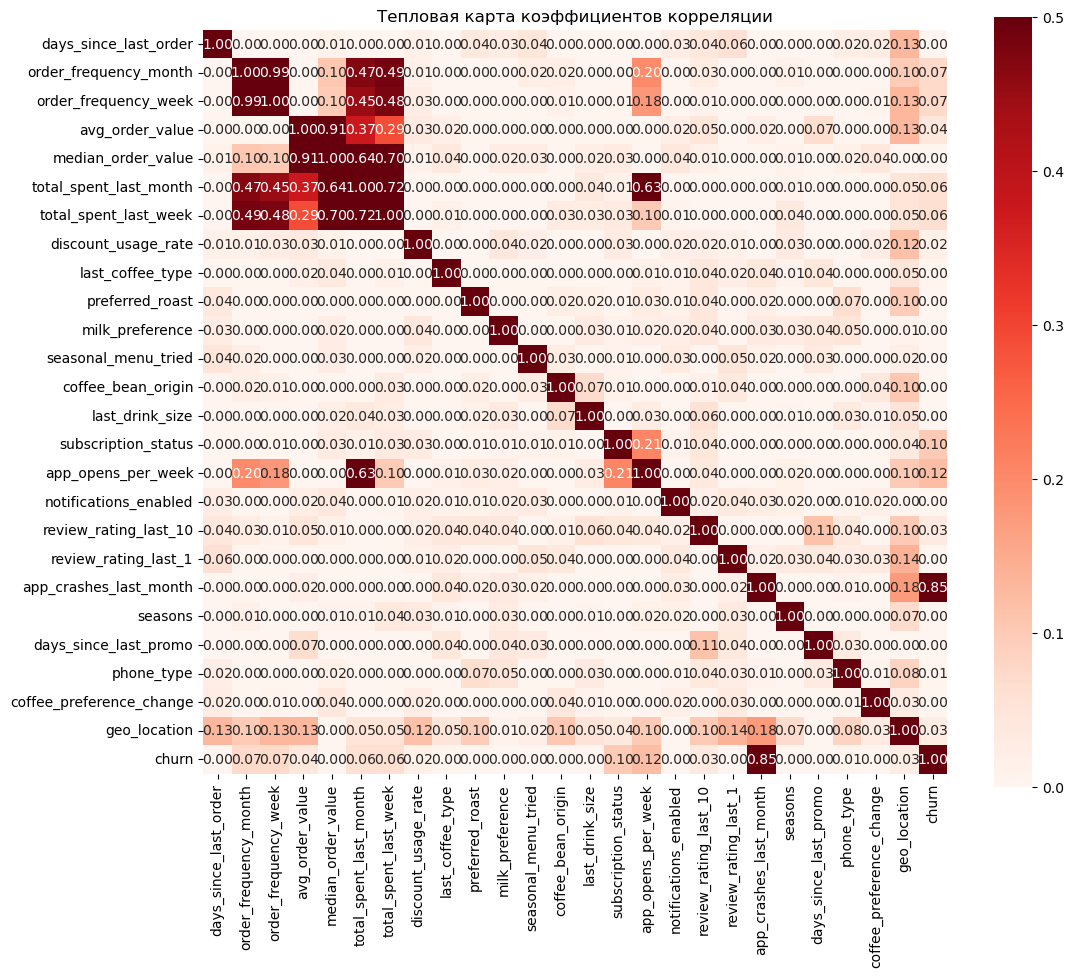

In [23]:
plt.figure(figsize=(12,10))

sns.heatmap(
    phik_corr,
    annot=True,
    cmap='Reds',
    fmt=".2f",
    square=True,
    vmin=0,
    vmax=0.5
)

plt.title('Тепловая карта коэффициентов корреляции')
plt.show()

import warnings
warnings.filterwarnings('ignore')

Анализ корреляции признаков с целевой переменной показал, что наибольшую связь с оттоком клиентов демонстрирует показатель app_crashes_last_month (коэффициент 0.85), что указывает на сильную зависимость между частотой сбоев приложения и вероятностью ухода клиента.

Остальные признаки имеют значительно более слабую связь с целевой переменной. Среди них можно выделить app_opens_per_week, subscription_status, order_frequency_month и total_spent_last_month, однако их корреляция остаётся на низком уровне (менее 0.15).

Большинство признаков демонстрируют нулевую или практически нулевую корреляцию с оттоком. Это может указывать на отсутствие линейной зависимости либо на наличие более сложных, нелинейных взаимосвязей, которые не выявляются с помощью корреляционного анализа.

Таким образом, можно сделать вывод, что отдельные признаки по отдельности слабо объясняют отток клиентов, за исключением частоты сбоев приложения, и для построения эффективной модели требуется учитывать совокупность признаков и их взаимодействие.

In [24]:
df = df.drop(columns=['median_order_value'])

Признак median_order_value был удалён, поскольку не демонстрирует связи с целевой переменной и дублирует информацию, содержащуюся в avg_order_value.

<div class="alerфt alert-info">
В итоге после анализа корреляции я решила удалить только 'median_order_value', потому что кроме того, что он дублирующий и может создавать мультиколлинеарность, он ещё и (по крайней мере в одиночку) никак не влияет на целевую переменную. Изначально я только его и удаляла в EDA, потом пообщавшись с одногруппниками, решила ещё два убрать. Теперь на два других признака ('order_frequency_week', 'total_spent_last_week') посмотрю в части с коэффициентами.
</div>

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Здесь используешь phik. Это непараметрический подход и он может учитывать нелинейные зависимости. Это стоит учитывать. Однако все верно, наши зависимости могут быть также и в сочетании факторов. 
    
Здесь хорошо подводим к аргументации создания новых признаков. Давай тогда идеи по новым признакам перенесем из начала проекта сюда и попробуем более подробно расписать, какие преобразования и почему могут сработать. Так будет гораздо нагляднее и убедительнее.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Стоит добавить промежуточный вывод по всему исследованию: какие проблемы выявили, какие решения приняли. Можно в промежуточном выводе и описать, какие признаки будем создавать.

В ходе исследовательского анализа данных были изучены структура датасета, распределения признаков и их связь с целевой переменной.


Было установлено, что целевая переменная имеет выраженный дисбаланс классов: доля ушедших клиентов значительно меньше доли оставшихся. Это необходимо учитывать при оценке качества модели и выборе метрик, в частности использовать PR-AUC и обращать внимание на полноту (recall).


В данных присутствуют пропущенные значения как в числовых, так и в категориальных признаках. Удаление строк с пропусками признано нецелесообразным из-за риска потери значительной части данных, поэтому было принято решение заполнять пропуски: для числовых признаков — медианными значениями, для категориальных — наиболее частым значением.


Анализ распределений показал наличие правосторонней асимметрии и выбросов в ряде числовых признаков. Большинство выбросов отражают реальные особенности поведения пользователей, поэтому они не удалялись. Исключение составило единичное экстремальное значение в признаке total_spent_last_month, которое было удалено как потенциальная аномалия.


В ходе анализа признаков были выявлены избыточные переменные. Признак median_order_value был удалён, так как не демонстрирует связи с целевой переменной и дублирует информацию, содержащуюся в avg_order_value.


Также был удалён признак user_id, не несущий полезной информации для предсказания.

Некоторые признаки могут быть использованы для создания новых.

Например, средние чеки пользователей за месяц:

total_spent_last_month / order_frequency_month
Также можно возвести в квадрат признак ошибок приложения, чтобы чтобы подчеркнуть раздражение от высокого количества ошибок:

app_crashes_last_month ** 2
Кроме того, после изучения распределения признаков, можно подумать о применении квадратного корня к признакам со скошенным распределением.

<div class="alerфt alert-info">
Решила убрать совсем мутный признак, который пыталась создать и вместо него попробовать тот, который ты предлагаешь.
</div>

<a id='section3'></a>
## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [25]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

In [26]:
cat_features = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'seasonal_menu_tried',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'notifications_enabled',
    'seasons',
    'phone_type',
    'coffee_preference_change',
    'geo_location'
]

num_features = [
    'days_since_last_order',
    'order_frequency_month',
    'avg_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'review_rating_last_10',
    'review_rating_last_1',
    'app_crashes_last_month',
    'days_since_last_promo',
    'app_opens_per_week'
]

In [27]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
 <font color='4682B4'> Я не очень понимаю формулировку задания тут. Написано создать пайплайн, который проведет масштабирование И нормализацию, но разве нормализация -- это не тип масштабирования? Я рискнула сделать стандартизацию, а не MinMaxScaler, потому что в данных все ещё есть выбросы, которые кажутся нормальным поведением пользователей, а StandardScaler к ним менее чувствителен.
 Кроме того, я не очень понимаю, зачем создавать отдельный пайплайн для выбросов и пропусков, если пропуски необходимо обработать в зависимости от типа признаков (вроде как нельзя обработать пропуски в категориальных данных так же, как и в числовых, только если речь не про удаление).</font>
 </div>

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍
    
Везде правильно рассуждаешь.
    
Масштабирование, скалирование и нормализация чаще используются как полные синонимы, но в наших учебных материалах скалирование - минмакс, нормализация - стандартскелер. В принципе можем попробовать как параметр использовать два подхода, но достаточно будет одного. В принципе оба подхода примерно одинаково справляются с выбросами, здесь я бы не говорил, что минмакс как-то лучше (можно помучать на этот счет нейросетку, но кажется, что все вытекает из формул этих подходов. Разница там в дисторции и все). 
    
`зачем создавать отдельный пайплайн для выбросов и пропусков,` - а правда, зачем отдельный? Все обозначим в пайплайнах для категориальных и количественных признаков. Выбросы можно вообще обработать на этапе подготовки данных, до пайплайнов. В реальных проектах так делают, когда обрабатывают аномалии в специальных функциях-хендлерах.
    



In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_features),
        ('num', num_pipe, num_features)
    ]
)

<a id='section4'></a>
## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [29]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

res = cross_validate(
    baseline_model,
    X_train,
    y_train,
    scoring=['average_precision','roc_auc', 'precision', 'recall', 'f1'],
    cv=cv
)

cv_df = pd.DataFrame({
    'pr_auc': res['test_average_precision'],
    'roc_auc': res['test_roc_auc'],
    'precision': res['test_precision'],
    'recall': res['test_recall'],
    'f1': res['test_f1']
})

cv_df

,pr_auc,roc_auc,precision,recall,f1
0,0.059729,0.5,0.0,0.0,0.0
1,0.060345,0.5,0.0,0.0,0.0
2,0.059766,0.5,0.0,0.0,0.0
3,0.059766,0.5,0.0,0.0,0.0
4,0.059766,0.5,0.0,0.0,0.0


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Все замечательно.

Базовая модель была обучена с использованием стратифицированной кросс-валидации.

По результатам оценки качества получены следующие значения метрик: ROC-AUC ≈ 0.5, PR-AUC ≈ 0.06, precision = 0, recall = 0 и F1 = 0.

Значение ROC-AUC, равное 0.5, указывает на то, что модель не способна различать классы. Нулевые значения precision, recall и F1-меры свидетельствуют о том, что модель не предсказывает ни одного случая оттока.

Значение PR-AUC близко к доле положительного класса в выборке (около 6%), что подтверждает отсутствие способности модели выявлять клиентов, склонных к уходу.

Такие результаты объясняются тем, что модель всегда предсказывает наиболее частый класс (отсутствие оттока), игнорируя редкий класс. 

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Ага, тут все результаты вытекают из формул метрик и дисбаланса классов. 

<a id='section5'></a>
## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [30]:
df_fe = df.copy() #копия датасета для создания дополнительных признаков

In [31]:
#модель логистической регрессии без новых признаков

logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

res = cross_validate(
    logreg_model,
    X_train,
    y_train,
    scoring=['average_precision', 'roc_auc', 'precision', 'recall', 'f1'],
    cv=cv
)

cv_df = pd.DataFrame({
    'pr_auc': res['test_average_precision'],
    'roc_auc': res['test_roc_auc'],
    'precision': res['test_precision'],
    'recall': res['test_recall'],
    'f1': res['test_f1'],
})

cv_summary = pd.DataFrame({
    'mean': cv_df.mean(),
    'std': cv_df.std()
}).round(3)

display(cv_df)

display(cv_summary)

,pr_auc,roc_auc,precision,recall,f1
0,0.704708,0.942972,0.813559,0.494845,0.615385
1,0.573892,0.899938,0.678571,0.387755,0.493506
2,0.640156,0.920133,0.708333,0.350515,0.468966
3,0.642067,0.917951,0.745763,0.453608,0.564103
4,0.659289,0.932098,0.727273,0.494845,0.588957


,mean,std
pr_auc,0.644,0.047
roc_auc,0.923,0.016
precision,0.735,0.051
recall,0.436,0.065
f1,0.546,0.063


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

удобнее результаты выводить через display(), а не print(), так форматирование не будет съезжать, глазам будет приятнее все считывать.

In [32]:
#новые признаки
df_fe['sqrt_app_opens_per_week'] = np.sqrt(df_fe['app_opens_per_week'])
df_fe['sqrt_days_since_last_promo'] = np.sqrt(df_fe['days_since_last_promo'])
df_fe['sqrt_total_spent_last_month'] = np.sqrt(df_fe['total_spent_last_month'])
df_fe['sq_total_spent_last_month'] = df_fe['total_spent_last_month'] ** 2
df_fe['sq_app_crashes_last_month'] = df_fe['app_crashes_last_month'] ** 2
df_fe['spent_per_order_month'] = df_fe['total_spent_last_month'] / df_fe['order_frequency_month']

Для признаков с выраженными выбросами (app_opens_per_week, days_since_last_promo, total_spent_last_month) было применено извлечение квадратного корня. Это позволило сгладить распределение значений и уменьшить влияние экстремально больших наблюдений на модель.

Для total_spent_last_month дополнительно было использовано возведение в квадрат, что усиливает вклад клиентов с высокими расходами и позволяет модели лучше учитывать их поведение. Также в квадрат был возведён признак app_crashes_last_month, чтобы подчеркнуть раздражение от большого количества ошибок.

Также был добавлен признак spent_per_order_month, рассчитанный как отношение суммарных расходов к частоте заказов, характеризует средний чек клиента в месяц и позволяет учесть особенности потребительского поведения.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Ну допустим. total_spent_last_month в квадрате - несколько неожиданно, но логика в аргументации прослеживается. Попробуем. Вдруг у нас таких клиентов хорошо бы выделить отдельным признаком.
    
Смотри, еще очевидное преобразование - квадрат от ошибок придложения. Чем больше ошибок, тем выше вероятность ухода. Явно, что раздражение от высокого количества ошибок нужно подчеркнуть. 
    
Уточню: деление, умножение, сумма и разность - линейные преобразования. Важно проверять, что получившиеся признаки не коррелируют с изначальными близко к единице. Здесь хорошо бы следить за мультиколлинеарностью.
    
Логарифмирование и степенные преобразования - нелинейные преобразования, в теории тут риски мультиколлинеаности ниже. Однако и такие признаки могут высоко коррелировать с изначальными, важно по весам признаков понять, нужно ли оставлять изначальные, если модифицированные признаки хорошо сработали. Всегда лучше избегать избыточности признаков.

In [33]:
X_fe = df_fe.drop(columns='churn')
y_fe = df_fe['churn']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe,
    test_size=0.2,
    random_state=random_state,
    stratify=y_fe
)

In [34]:
new_num_features = num_features + [
    'sqrt_app_opens_per_week',
    'sqrt_days_since_last_promo',
    'sqrt_total_spent_last_month',
    'sq_total_spent_last_month',
    'spent_per_order_month'
]

In [35]:
preprocessor_new = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_features),
        ('num', num_pipe, new_num_features)
    ]
)

In [36]:
logreg_model_new = Pipeline([
    ('preprocessor', preprocessor_new),
    ('model', LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

res = cross_validate(
    logreg_model_new,
    X_train_fe,
    y_train_fe,
    scoring=['average_precision', 'roc_auc', 'precision', 'recall', 'f1'],
    cv=cv
)

cv_df_fe = pd.DataFrame({
    'pr_auc': res['test_average_precision'],
    'roc_auc': res['test_roc_auc'],
    'precision': res['test_precision'],
    'recall': res['test_recall'],
    'f1': res['test_f1']
})

cv_fe_summary = pd.DataFrame({
    'mean': cv_df_fe.mean(),
    'std': cv_df_fe.std()
}).round(3)

print(cv_df_fe)

print(cv_fe_summary)

     pr_auc   roc_auc  precision    recall        f1
0  0.713050  0.949952   0.809524  0.525773  0.637500
1  0.617775  0.911219   0.687500  0.448980  0.543210
2  0.687704  0.933476   0.769231  0.412371  0.536913
3  0.677401  0.930362   0.746269  0.515464  0.609756
4  0.718771  0.942650   0.791045  0.546392  0.646341
            mean    std
pr_auc     0.683  0.040
roc_auc    0.934  0.015
precision  0.761  0.047
recall     0.490  0.057
f1         0.595  0.052


После добавления новых признаков качество модели улучшилось по всем основным метрикам.

Значение PR-AUC увеличилось с 0.644 до 0.683, что свидетельствует о повышении способности модели выявлять клиентов, склонных к оттоку. Поскольку PR-AUC является основной метрикой задачи, данное улучшение особенно важно.

Значение ROC-AUC также выросло с 0.923 до 0.934, что указывает на улучшение общей способности модели различать классы.

Метрики precision, recall и F1-мера также продемонстрировали положительную динамику: precision увеличилась с 0.735 до 0.761, recall — с 0.436 до 0.490, а F1-мера — с 0.546 до 0.595. Особенно значим рост recall, что означает улучшение способности модели выявлять клиентов, склонных к уходу.

Таким образом, добавление новых признаков позволило модели лучше учитывать нелинейные зависимости и взаимодействия между переменными, что привело к повышению качества предсказаний.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Молодец. В этом проекте осмысленный подход к созданию фичей часто дает хороший прирост по качеству.   ( Удивительно, как много студентов при этом создают признаки с помощью ИИ и заключают, что новые признаки только ухудшают качество )

In [37]:
logreg_model_new.fit(X_train_fe, y_train_fe)

model = logreg_model_new.named_steps['model'] 

coefs = model.coef_[0]

feature_names = logreg_model_new.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})

coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=True)

pd.set_option('display.max_rows', None)
coef_df

,feature,coef,abs_coef
6,cat__milk_preference_almond,-0.001762,0.001762
142,num__discount_usage_rate,-0.001838,0.001838
91,cat__geo_location_geo_57,-0.004735,0.004735
50,cat__geo_location_geo_2,0.010691,0.010691
48,cat__geo_location_geo_18,0.011265,0.011265
45,cat__geo_location_geo_15,-0.019913,0.019913
40,cat__geo_location_geo_100,-0.029215,0.029215
70,cat__geo_location_geo_38,0.031096,0.031096
14,cat__coffee_bean_origin_brazil,0.032526,0.032526
69,cat__geo_location_geo_37,-0.040255,0.040255


In [38]:
new_cat_features = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'seasonal_menu_tried',
    'coffee_bean_origin',
    'last_drink_size',
    'subscription_status',
    'notifications_enabled',
    'seasons',
    'phone_type',
    'coffee_preference_change'
]

new_num_features = [
    col for col in new_num_features
    if col not in ['order_frequency_week', 'total_spent_last_week']
]

In [39]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, new_cat_features),
        ('num', num_pipe, new_num_features)
    ]
)

Анализ коэффициентов логистической регрессии показал, что наибольшее влияние на вероятность оттока оказывают признаки, связанные с частотой сбоев приложения и активностью пользователей. В частности, увеличение количества сбоев (app_crashes_last_month) значительно повышает вероятность ухода клиента.

Финансовые показатели также оказывают влияние на поведение клиентов: более высокий средний чек способствует удержанию пользователей, тогда как влияние суммарных расходов носит неоднозначный характер и усиливается при использовании нелинейных преобразований.

Признаки order_frequency_week, geo_location и total_spent_last_week были удалены в виду наличия слабой корреляции с целевой переменной, а также из-за наличия мультиколлинеарности.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Кажется, все логично, интуитивно объяснимо. 
    
Можем попробовать обучить также модельку с умеренной регуляризацией, посмотреть, какие признаки занулятся, какое качество будет. Если качество не снизилось, можем убрать какие-то занулившиеся признаки. 

In [40]:
logreg_model_fe = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

res = cross_validate(
    logreg_model_fe,
    X_train_fe,
    y_train_fe,
    scoring=['average_precision', 'roc_auc', 'precision', 'recall', 'f1'],
    cv=cv
)

cv_df_fe = pd.DataFrame({
    'pr_auc': res['test_average_precision'],
    'roc_auc': res['test_roc_auc'],
    'precision': res['test_precision'],
    'recall': res['test_recall'],
    'f1': res['test_f1']
})

cv_fe_summary = pd.DataFrame({
    'mean': cv_df_fe.mean(),
    'std': cv_df_fe.std()
}).round(3)

print(cv_df_fe)

print(cv_fe_summary)

     pr_auc   roc_auc  precision    recall        f1
0  0.741793  0.953045   0.842105  0.494845  0.623377
1  0.618667  0.911774   0.666667  0.428571  0.521739
2  0.703029  0.932483   0.785714  0.453608  0.575163
3  0.686302  0.928909   0.770492  0.484536  0.594937
4  0.719117  0.942630   0.782609  0.556701  0.650602
            mean    std
pr_auc     0.694  0.047
roc_auc    0.934  0.015
precision  0.770  0.064
recall     0.484  0.048
f1         0.593  0.049


После удаления признаков geo_location, order_frequency_week и total_spent_last_week качество модели осталось на сопоставимом уровне по большинству метрик, при этом значение основной метрики PR-AUC увеличилось с 0.683 до 0.694.

Незначительные изменения в значениях ROC-AUC, precision, recall и F1-меры находятся в пределах статистической погрешности и не оказывают существенного влияния на качество модели.

Это подтверждает, что данные признаки не вносили значимого вклада в предсказание оттока, несмотря на большое количество категорий после кодирования.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Прекрасно. Вот по аналогии с геолокацией можно исследовать и удалить остальные признаки, которые в начале проекта сносим. Скорее всего они действительно лишние, но вроде бы это в самом начале неочевидно.

<a id='section6'></a>
## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

В рамках настройки модели логистической регрессии планируется провести эксперимент с гиперпараметром C — коэффициентом регуляризации, влияющим на сложность модели.
Были выбраны значения 0.01, 0.1, 1 и 10, позволяющие исследовать поведение модели при различной степени регуляризации — от сильной до слабой.

Кроме того, так как задача проекта заключается в выявлении клиентов с риском ухода, было принято решение также исследовать влияние порога классификации на качество модели, конкретно на метрику Recall.

In [41]:
results = []

for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=c, max_iter=2000, random_state=random_state)
    
    logreg = Pipeline([
        ('preprocessor', preprocessor_fe),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    res = cross_validate(
        logreg,
        X_train_fe,
        y_train_fe,
        scoring=['average_precision', 'roc_auc', 'precision', 'recall', 'f1'],
        cv=cv
    )
    results.append({
        'C': c,
        'pr_auc_mean': res['test_average_precision'].mean(),
        'pr_auc_std': res['test_average_precision'].std(),
        
        'roc_auc_mean': res['test_roc_auc'].mean(),
        'roc_auc_std': res['test_roc_auc'].std(),
        
        'precision_mean': res['test_precision'].mean(),
        'precision_std': res['test_precision'].std(),
        
        'recall_mean': res['test_recall'].mean(),
        'recall_std': res['test_recall'].std(),
        
        'f1_mean': res['test_f1'].mean(),
        'f1_std': res['test_f1'].std()
    })

results_df = pd.DataFrame(results).round(3)

results_df

,C,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,0.01,0.683,0.042,0.927,0.016,0.952,0.028,0.276,0.048,0.425,0.056
1,0.10,0.692,0.041,0.932,0.014,0.806,0.045,0.440,0.047,0.568,0.045
2,1.00,0.694,0.042,0.934,0.014,0.770,0.057,0.484,0.043,0.593,0.044
3,10.00,0.692,0.042,0.934,0.014,0.764,0.056,0.502,0.036,0.606,0.040


Наилучший результат по основной метрике PR-AUC показала модель с C = 1 (PR-AUC = 0.694). При этом значения остальных метрик также остаются на высоком уровне, обеспечивая сбалансированное качество модели.

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
 <font color='4682B4'> После удаления старого сгенерированного мной признака и добавления нового (квадрат ошибок приложения) результаты по гиперпараметру C тоже изменились, теперь лучшая модель с дефолтным C = 1.</font>
 </div>

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Все-таки оптимальная регуляризация скорее что-то еще убирает из признаков или занижает. 

In [42]:
#эксперимент с порогом классификации
threshold_model = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(C=1, max_iter=2000, random_state=random_state))
])

threshold_model.fit(X_train_fe, y_train_fe)

y_proba_train = threshold_model.predict_proba(X_train_fe)[:, 1]

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_proba_train >= t).astype(int)
    
    print(
        'threshold =', t,
        'recall =', round(recall_score(y_train_fe, y_pred), 3),
        'precision =', round(precision_score(y_train_fe, y_pred), 3),
        'f1 =', round(f1_score(y_train_fe, y_pred), 3)
    )

threshold = 0.2 recall = 0.759 precision = 0.532 f1 = 0.626
threshold = 0.3 recall = 0.689 precision = 0.615 f1 = 0.65
threshold = 0.4 recall = 0.607 precision = 0.713 f1 = 0.656
threshold = 0.5 recall = 0.506 precision = 0.809 f1 = 0.623


В ходе эксперимента были рассмотрены значения порога классификации 0.2, 0.3, 0.4 и 0.5. Результаты показали, что снижение порога приводит к существенному увеличению полноты модели: при пороге 0.2 значение recall достигает 0.76, тогда как при стандартном пороге 0.5 оно составляет лишь 0.49.

При этом наблюдается ожидаемое снижение precision: при уменьшении порога увеличивается количество ложноположительных предсказаний. Однако при пороге 0.3 достигается наиболее сбалансированный результат: recall составляет 0.68, precision — 0.61, а значение F1-меры достигает 0.65.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 )) как в анекдоте «В результате многолетних исследований муравейников в Московской области было твердо установлено: Отношение длины окружности любого муравейника к его диаметру, есть величина постоянная, приблизительно равная 3». 
    
ну да, по определению когда двигаем порог, то играем с балансом полноты и точности.

<a id='section7'></a>
## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [43]:
final_model = Pipeline([
    ('preprocessor', preprocessor_fe),
    ('model', LogisticRegression(C=0.1, max_iter=2000, random_state=random_state))
])

final_model.fit(X_train_fe, y_train_fe)

y_proba = final_model.predict_proba(X_test_fe)[:, 1]

threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)

In [44]:
pr_auc = average_precision_score(y_test_fe, y_proba)
roc_auc = roc_auc_score(y_test_fe, y_proba)
precision = precision_score(y_test_fe, y_pred)
recall = recall_score(y_test_fe, y_pred)
f1 = f1_score(y_test_fe, y_pred)

print(f'pr_auc: {pr_auc}\nroc_auc: {roc_auc}\nprecision: {precision}\nrecall:{recall}\nf1:{f1}')

pr_auc: 0.7442344618291723
roc_auc: 0.935836771447991
precision: 0.635036496350365
recall:0.71900826446281
f1:0.6744186046511628


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично, стабильно по качеству.

<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
 <font color='4682B4'>Интересно, в изначальной версии, где присутствовал сгенерирвоанный мной признак про взаимодействие с приложением, модель на тренировочной выборке показывала результаты в среднем лучше, чем те, что показывала модель без этого признака, но с признаком ошибок приложения в квадрате, зато на тестовой выборке предыдущая модель проседала по метрикам в сравнении с обучающей выборкой, а новая модель наоборот показывает более высокие результаты. </font>
 </div>

<a id='section8'></a>
## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

В ходе выполнения проекта была построена модель логистической регрессии для прогнозирования вероятности оттока клиентов сервиса доставки кофе. Итоговая модель была обучена с использованием оптимального значения гиперпараметра регуляризации C = 1 и оценена на отложенной тестовой выборке.

По результатам тестирования модель продемонстрировала следующие значения метрик: PR-AUC = 0.744, ROC-AUC = 0.935, precision = 0.635, recall = 0.71 и F1-мера = 0.67. Значение PR-AUC значительно превышает показатель базовой модели, что свидетельствует о высокой способности модели выявлять клиентов, склонных к оттоку. Высокое значение ROC-AUC подтверждает хорошую разделяющую способность модели.

Существенное влияние на качество модели оказали этапы предобработки данных и создания новых признаков. В частности, добавление нелинейных преобразований (извлечение квадратного корня и возведение в квадрат) позволило учесть сложные зависимости в данных, а введение признаков взаимодействия (например, произведение числа сбоев и активности пользователя) улучшило способность модели отражать поведение клиентов.

Также важным этапом стало удаление признака geo_location, который после кодирования создавал большое количество слабоинформативных переменных. Его исключение позволило упростить модель и даже незначительно улучшить значение основной метрики PR-AUC.

Значительное влияние на итоговые метрики оказал выбор порога классификации. При стандартном пороге 0.5 модель демонстрировала высокую точность, но низкую полноту. Снижение порога до 0.3 позволило существенно увеличить recall (с 0.48 до 0.64), что особенно важно в задаче выявления клиентов с риском ухода. При этом точность снизилась до 0.60, однако значение F1-меры выросло, что свидетельствует об улучшении общего баланса между метриками.

Таким образом, наибольшее влияние на качество модели оказали:
	•	создание новых признаков, отражающих нелинейные зависимости и взаимодействия;
	•	удаление слабоинформативных признаков, увеличивающих размерность данных;
	•	подбор гиперпараметра регуляризации;
	•	настройка порога классификации в соответствии с задачей.

В результате была получена модель, способная эффективно выявлять клиентов, склонных к оттоку, и адаптированная под специфику задачи за счёт настройки порога классификации.

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍

<a id='section9'></a>
## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [45]:
joblib.dump(final_model, 'coffee_churn_model.joblib')

['coffee_churn_model.joblib']

In [46]:
loaded_model = joblib.load('coffee_churn_model.joblib')

y_pred_loaded = loaded_model.predict(X_test_fe)
y_proba_loaded = loaded_model.predict_proba(X_test_fe)[:, 1]

pr_auc_loaded = average_precision_score(y_test_fe, y_proba_loaded)
roc_auc_loaded = roc_auc_score(y_test_fe, y_proba_loaded)
precision_loaded = precision_score(y_test_fe, y_pred_loaded)
recall_loaded = recall_score(y_test_fe, y_pred_loaded)
f1_loaded = f1_score(y_test_fe, y_pred_loaded)

print(f'pr_auc: {pr_auc_loaded}')
print(f'roc_auc: {roc_auc_loaded}')
print(f'precision: {precision_loaded}')
print(f'recall: {recall_loaded}')
print(f'f1: {f1_loaded}')

pr_auc: 0.7442344618291723
roc_auc: 0.935836771447991
precision: 0.8024691358024691
recall: 0.5371900826446281
f1: 0.6435643564356436


После загрузки сохранённой модели было проведено повторное тестирование на отложенной выборке. При использовании стандартного метода predict() были получены значения метрик, отличающиеся от ранее рассчитанных.

Это связано с тем, что метод predict() использует порог классификации 0.5, тогда как в ходе экспериментов было установлено, что для данной задачи более подходящим является порог 0.3.

При применении выбранного порога к вероятностям, полученным с помощью метода predict_proba(), значения метрик совпадают с ранее рассчитанными.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Порог подбирать пока не нужно, его подберем под бизнес-задачи. Если нужно удерживать как можно больше клиентов - снижаем порог, если удержание стоит дорого и выгодно удерживать только самых склонных к оттоку - повышаем. Пока без дополнительных вводных сказать про оптимальный порог ничего не можем. 
    
Не торопись с выводами, дожидайся вводных и полноты информации, лучше отражай, что мы определенно знаем на каждом этапе.

https://github.com/spielraum79/Happy-Beans-Model

<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 супер по ссылке.

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект! Крутая интересная вдумчивая самостоятельная работа с вниманием к деталям и хорошим погружением в контекст. Очень приятно проверять.
    
**Отмечу положительные моменты проекта🚀**
    
* Хорошая схема проекта.
* Отличные решения в коде, все оптимально, прозрачно, понятно.
* Есть пояснения и аргументация решений.
    
**На что стоит обратить внимание🤔**
    
Общее - на каждом этапе анализируй, что мы уже знаем, а что только предполагаем. Не принимай решения раньше времени, если по ним есть неполнота информации и если решений от нас на этом этапе не требуют. Спрашивай себя, чего не хватает, можем ли мы это узнать. Если да, узнаем, тогда принимаем решения (как в случае с признаками). Если нет - пишем в выводах, чего не хватило, что предполагаем (как в случае с порогом). Так мы будем двигаться безопаснее, минимизируем риск ошибок, не будем брать на себя ответственность за какие-то утверждения, которые могут потом не оправдаться и привести к финансовым потерям. 
    
* предлагаю перенести удаление признаков в часть после их исследования.
    
* Эти и остальные замечания я также написал по ходу проекта.
    
Если остались вопросы − обчзательно задавай.
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>